# Phase 2: Unsupervised Discovery (Topic Modeling)

## set up

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Setup Thai font for matplotlib
!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

print("Setup complete. Libraries and models are ready.")

Setup complete. Libraries and models are ready.


In [2]:
%pip install pythainlp gensim pyldavis

Note: you may need to restart the kernel to use updated packages.


## load dataset

In [3]:
from datasets import load_dataset

# thaipbs-news dataset (scraped)
tpbs_ds = load_dataset("szzs1693/nlp-thaipbs-news")

In [4]:
tpbs_df = tpbs_ds['train'].to_pandas()
tpbs_df.head()

,url,title,categoryName,abstract,publishedTime,tags,content_html,content_text
0,https://www.thaipbs.or.th/news/content/355884,"""อาร์เจนตินา"" ประตูสู่ ลาตินอเมริกา โอกาส ""ยา...",เศรษฐกิจ,,2025-09-01 03:38:00,"[อาร์เจนตินา, ส่งออกสินค้าไทย, ตลาดส่งออกไทย, ...","<p><strong><em>""บัวโนสไอเรส"" เมืองหลวงของอาร์เ...","""บัวโนสไอเรส"" เมืองหลวงของอาร์เจนตินา ตั้งอยู่..."
1,https://www.thaipbs.or.th/news/content/356014,“เนื้อโคขุน” สุรินทร์ ของดีเมืองไทย รสชาตินุ่ม...,เศรษฐกิจ,,2025-09-02 04:43:00,"[เนื้อสุรินทร์, เนื้อโคขุน, เนื้อโค, โคขุน, จั...",<p><em><strong>“สีแดงอมชมพู ลายไขมันแทรกสวย” เ...,“สีแดงอมชมพู ลายไขมันแทรกสวย” เมื่อปรุงสุกจะได...
2,https://www.thaipbs.or.th/news/content/356017,เปิดนำเข้าพ่อแม่พันธุ์ไก่ “รมว.เกษตรฯ”ถก บอร์ด...,เศรษฐกิจ,“รมว.เกษตรฯ” ถกบอร์ดไข่ไก่ ยันผู้ประกอบการขอนำ...,2025-09-01 08:40:00,"[ไข่ไก่, พ่อพันธุ์แม่พันธุ์ไก่, นำเข้าพ่อแม่พั...",<p>วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร...,วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร รม...
3,https://www.thaipbs.or.th/news/content/356047,พณ.ดันอาเซียน–อินเดีย ทบทวนข้อตกลงการค้าเปิดทา...,เศรษฐกิจ,พาณิชย์ ถกรมว.อาเซียน-อินเดีย ดันทบทวนความตกลง...,2025-09-02 05:40:40,"[ความตกลงการค้าสินค้าอาเซียน–อินเดีย, อาเซียนอ...",<p>วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ...,วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ์ ร...
4,https://www.thaipbs.or.th/news/content/356067,ไทยส่งออกสัตว์น้ำได้ฉลุย หลังสหรัฐฯประกาศผ่านเ...,เศรษฐกิจ,ข่าวดี สหรัฐฯ ประกาศ ไทยผ่านเกณฑ์มาตรฐาน MMPA ...,2025-09-02 08:59:13,"[กรมประมง, ส่งออกสัตว์น้ำ, สินค้าสัตว์น้ำไทย, ...",<p>วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบด...,วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบดีกร...


## LDA

In [5]:
from pythainlp.corpus.common import thai_words, thai_stopwords
from pythainlp.tokenize import Trie

# ----------------------------------
# Sometimes we want some word not to break into tokens
# which might broke token modeling (mistaken a subword as a topic)
# For example: กล้าธรรม may become กล้า / ธรรม when tokenize

# We can create a custom dict here, but we don't need to add every single word.
# Just look at the results, see if something looks wrong to be a topic

# Extend PyThaiNLP existing thai words corpus
custom_dict = set(thai_words())

trie = Trie(custom_dict)

# We also don't want Thai stop words to be a topic, even it is repeated a lot.
# PyThaiNLP has existing thai stop_words as well

stopwords = set(thai_stopwords())

EXTRA_STOPWORDS = ["ไทย", "ปี", "วันที่", "เรื่อง"]
for sw in EXTRA_STOPWORDS:
    stopwords.add(sw)

In [6]:
# # Custom text modifications
tpbs_df['text'] = tpbs_df['content_text']
# tpbs_df['text'] = tpbs_df['content_text'].str.replace("ลบ.ม.", "ลูกบาศก์เมตร")
# tpbs_df['text'] = tpbs_df['content_text'].str.replace("มค.ก.", "ไมโครกรัม")
tpbs_df['text'] = tpbs_df['text'].str.replace(" จ.", " จังหวัด")
tpbs_df['text'] = tpbs_df['text'].str.replace(" อ.", " อำเภอ")

In [7]:
from pythainlp.tokenize import word_tokenize

# Then we define a tokenize function
# with custom dict added, and filter tokens
# which aren't super short `len(t) > 1`
# and not in the stop_words

def tokenize(text):
    tokens = word_tokenize(text, engine='newmm', custom_dict=trie, keep_whitespace=False)
    return [
        t for t in tokens if t not in stopwords and len(t) > 1 and not t.isdigit()
    ]

# Merge and flatten all texts into a long list of tokens
# body_text is a column in the dataframe, change it to appropriate one
print("Tokenizing corpus...")
texts = [tokenize(t) for t in tpbs_df['text']]
print(f"Done. Avg tokens per doc: {sum(len(t) for t in texts)/len(texts):.0f}")

Tokenizing corpus...
Done. Avg tokens per doc: 280


In [8]:
# Run LDA on the full corpus to see what topics emerge

from gensim import corpora
from gensim.models import LdaModel

dictionary = corpora.Dictionary(texts)

corpus = [dictionary.doc2bow(t) for t in texts]
print(f"Vocabulary size: {len(dictionary)}")

lda = LdaModel(
    corpus, num_topics=7, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

print("\nTop 8 words per topic:")
for i, topic in lda.print_topics(num_words=8):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Vocabulary size: 22296

Top 8 words per topic:
  Topic 1: บาท, ล้าน, สินค้า, เศรษฐกิจ, ราคา, ประเทศ, ตลาด, ข้าว
  Topic 2: โครงการ, สิทธิ, คนละ, ครึ่ง, บาท, ประชาชน, ร้านค้า, พลัส
  Topic 3: คน, บาท, พื้นที่, คะแนน, จำนวน, ประชาชน, ตรวจสอบ, ถนน
  Topic 4: พื้นที่, กัมพูชา, เขต, จังหวัด, แขวง, ประชาชน, ชายแดน, ประเทศ
  Topic 5: พรรค, คน, สส., เขต, พรรคภูมิใจไทย, พรรคเพื่อไทย, ธรรม, รัฐบาล
  Topic 6: การเลือกตั้ง, ประชาชน, เลือกตั้ง, คน, กกต., สส., สิทธิ, คณะกรรมการ
  Topic 7: ประชาชน, ข้อมูล, ยา, โรงพยาบาล, โรค, คน, บริการ, ผู้ป่วย


## Visualizations

In [9]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda, corpus, dictionary, sort_topics=False)
pyLDAvis.display(vis)

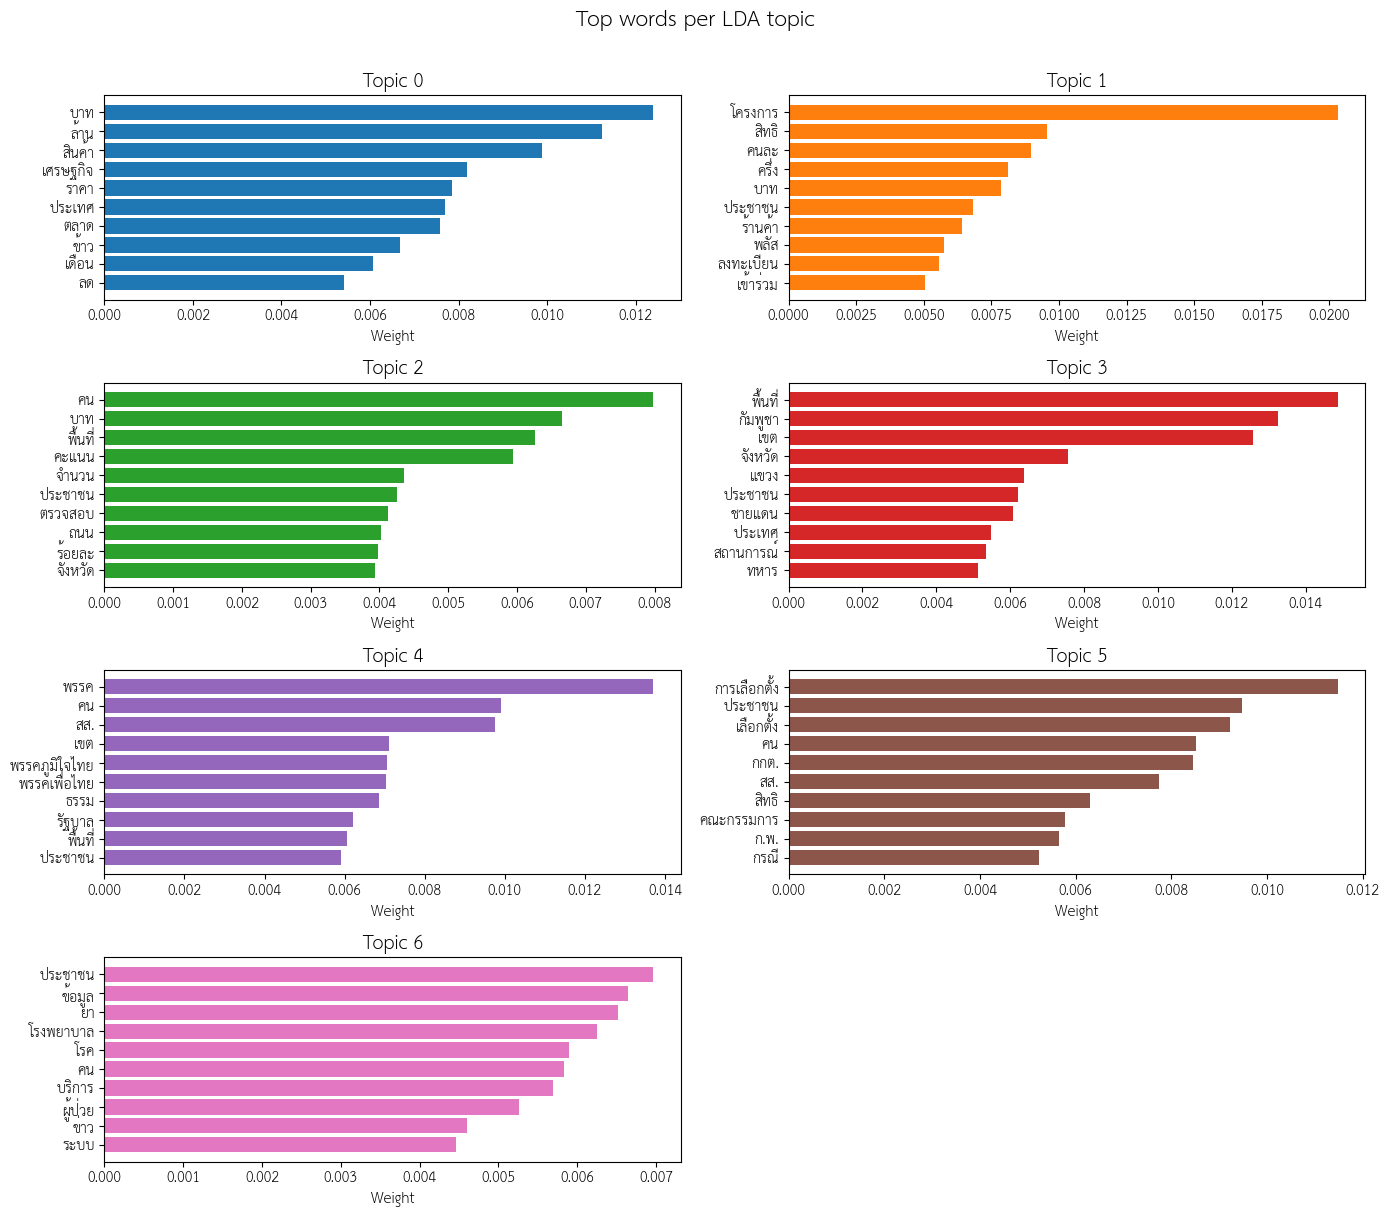

In [10]:
# Top words per topic — horizontal bar charts
NUM_WORDS = 10
num_topics = lda.num_topics

fig, axes = plt.subplots(nrows=(num_topics + 1) // 2, ncols=2, figsize=(14, 3 * ((num_topics + 1) // 2)))
axes = axes.flatten()

for i in range(num_topics):
    topic_terms = lda.show_topic(i, topn=NUM_WORDS)
    words = [w for w, _ in reversed(topic_terms)]
    weights = [p for _, p in reversed(topic_terms)]
    axes[i].barh(words, weights, color=f"C{i}")
    axes[i].set_title(f"Topic {i}", fontsize=13)
    axes[i].set_xlabel("Weight")

# Hide any unused subplot
for j in range(num_topics, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top words per LDA topic", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

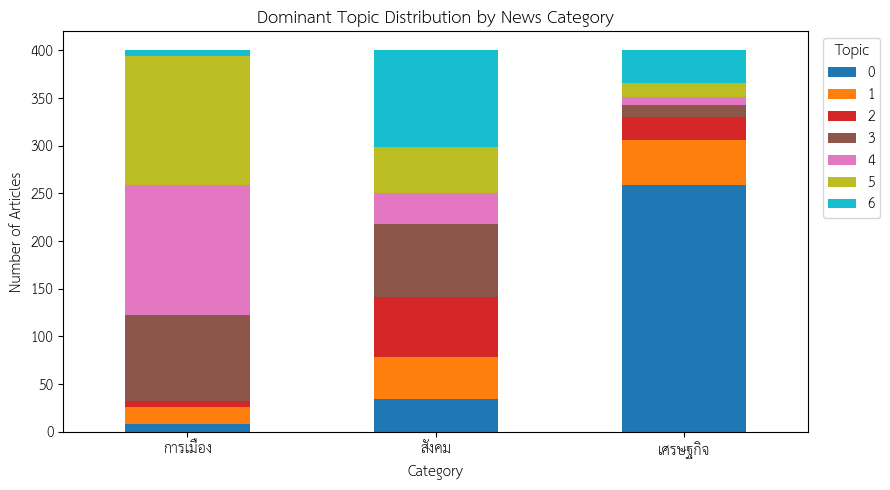

In [11]:
# Dominant topic per document — distribution by news category
def dominant_topic(bow):
    topics = lda.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

tpbs_df['dominant_topic'] = [dominant_topic(bow) for bow in corpus]

# Stacked bar: how each category's articles distribute across topics
pivot = tpbs_df.groupby(['categoryName', 'dominant_topic']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='tab10')
plt.title("Dominant Topic Distribution by News Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Inspect articles containing a specific token
# Change this to the token you want to investigate
INSPECT_TOKEN = "อ."

matches = [
    (i, tpbs_df.iloc[i]['title'], tpbs_df.iloc[i]['categoryName'], tpbs_df.iloc[i]['dominant_topic'], texts[i])
    for i in range(len(texts))
    if INSPECT_TOKEN in texts[i]
]

print(f"Found {len(matches)} articles containing '{INSPECT_TOKEN}':\n")
for idx, title, category, topic, tokens in matches[:10]:
    surrounding = []
    for j, t in enumerate(tokens):
        if t == INSPECT_TOKEN:
            surrounding.append(tokens[max(0, j-3):j+4])
    print(f"[{idx}] Topic {topic} | {category}")
    print(f"  Title: {title}")
    for ctx in surrounding[:3]:
        print(f"  Context: {' / '.join(ctx)}")
    print()

Found 95 articles containing 'อ.':

[12] Topic 1 | เศรษฐกิจ
  Title: ผู้ค้า-เอกชนหนุนรับ "คนละครึ่ง" หวังกระตุ้นเศรษฐกิจปลายปี
  Context: ครึ่ง / รัฐบาล / พล / อ. / ประยุทธ์ / จันทร์ / โอชา

[19] Topic 6 | เศรษฐกิจ
  Title: บอร์ด สมอ. ไฟเขียว “วงล้อรถยนต์” สินค้าควบคุม มีผลปี 69
  Context: ผลิตภัณฑ์ / อุตสาหกรรม / กม / อ. / มติ / การประชุม / บอร์ด
  Context: ผลิตภัณฑ์ / อุตสาหกรรม / กม / อ. / เห็นชอบ / วง / ล้อ

[48] Topic 1 | เศรษฐกิจ
  Title: "อนุทิน" ลั่นนำ "คนละครึ่ง" กลับมาใช้ คาดเร็วสุดกลาง ต.ค.นี้
  Context: เทียบ / รัฐบาล / พล / อ. / ประยุทธ์ / จันทร์ / โอชา

[91] Topic 0 | เศรษฐกิจ
  Title: กนง.มีมติ 5:2 เสียง คงอัตราดอกเบี้ยนโยบายที่ 1.50% ต่อปี 
  Context: เทียบ / ดอลลาร์ / สร / อ. / เคลื่อนไหว / แข็งค่า / จังหวะ

[99] Topic 6 | เศรษฐกิจ
  Title: คุม "ราคายา-เวชภัณฑ์" ช่วยค่าครองชีพ ไม่ใหม่ แต่ "คนไทย" ต้องรู้
  Context: ยา / รัฐบาล / พล / อ. / ประยุทธ์ / จันทร์ / โอชา

[104] Topic 3 | เศรษฐกิจ
  Title: TMAC ส่งชุดเครื่องจักรกวาดล้างทุ่นระเบิด หนุนกองกำลังบูรพา  
  Context: 

In [13]:
print("Topic distributions (top 15 words with probabilities):")
for i in range(lda.num_topics):
    print(f"Topic {i}:")
    topic_terms = lda.show_topic(i, topn=15)
    for word, prob in topic_terms:
        print(f"  - {word}: {prob:.4f}")

Topic distributions (top 15 words with probabilities):
Topic 0:
  - บาท: 0.0124
  - ล้าน: 0.0112
  - สินค้า: 0.0099
  - เศรษฐกิจ: 0.0082
  - ราคา: 0.0078
  - ประเทศ: 0.0077
  - ตลาด: 0.0076
  - ข้าว: 0.0067
  - เดือน: 0.0061
  - ลด: 0.0054
  - สหรัฐฯ: 0.0052
  - การค้า: 0.0048
  - จีน: 0.0048
  - มาตรการ: 0.0048
  - สำหรับ: 0.0045
Topic 1:
  - โครงการ: 0.0203
  - สิทธิ: 0.0096
  - คนละ: 0.0090
  - ครึ่ง: 0.0081
  - บาท: 0.0078
  - ประชาชน: 0.0068
  - ร้านค้า: 0.0064
  - พลัส: 0.0057
  - ลงทะเบียน: 0.0056
  - เข้าร่วม: 0.0050
  - เดือน: 0.0044
  - เงิน: 0.0043
  - ต.ค.: 0.0042
  - สำหรับ: 0.0042
  - คน: 0.0038
Topic 2:
  - คน: 0.0080
  - บาท: 0.0067
  - พื้นที่: 0.0063
  - คะแนน: 0.0059
  - จำนวน: 0.0044
  - ประชาชน: 0.0043
  - ตรวจสอบ: 0.0041
  - ถนน: 0.0040
  - ร้อยละ: 0.0040
  - จังหวัด: 0.0039
  - เขต: 0.0037
  - สินค้า: 0.0035
  - อาคาร: 0.0034
  - เจ้าหน้าที่: 0.0032
  - ประเทศ: 0.0031
Topic 3:
  - พื้นที่: 0.0149
  - กัมพูชา: 0.0133
  - เขต: 0.0126
  - จังหวัด: 0.0076
  - แขวง: 0